In [1]:
# Cell 1: Imports & Setup
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Metrics
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import lpips

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")

Using compute device: cuda


In [14]:
# Cell 2: Dataset, Augmentation Pipeline, and Train/Val Split
import os
import glob
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class KLAHackathonDataset(Dataset):
    def __init__(self, gt_paths, noisy_paths, lr_crop_size=64, train=True):
        self.gt_paths = gt_paths
        self.noisy_paths = noisy_paths
        self.lr_crop_size = lr_crop_size
        self.train = train
        
        if len(self.gt_paths) == 0 or len(self.noisy_paths) == 0:
            raise RuntimeError("Empty file list provided. Check your split logic or paths.")
        
        assert len(self.gt_paths) == len(self.noisy_paths), "Mismatch between GT and Noisy images."
        print(f"Loaded {len(self.gt_paths)} image pairs for {'Training' if train else 'Validation'}.")

    def __len__(self):
        return len(self.gt_paths)

    def __getitem__(self, idx):
        # Load grayscale .npy arrays
        gt_img = np.load(self.gt_paths[idx]).astype(np.float32)
        noisy_img = np.load(self.noisy_paths[idx]).astype(np.float32)
        
        
        if self.train:
            h_lr, w_lr = noisy_img.shape
            
            # 1. Random Spatial Crop
            if h_lr > self.lr_crop_size and w_lr > self.lr_crop_size:
                x = random.randint(0, w_lr - self.lr_crop_size)
                y = random.randint(0, h_lr - self.lr_crop_size)
                
                noisy_img = noisy_img[y:y + self.lr_crop_size, x:x + self.lr_crop_size]
                gt_img = gt_img[y * 2:(y + self.lr_crop_size) * 2, x * 2:(x + self.lr_crop_size) * 2]
            
            # 2. Geometric Flips
            if random.random() > 0.5:
                noisy_img = np.fliplr(noisy_img)
                gt_img = np.fliplr(gt_img)
            if random.random() > 0.5:
                noisy_img = np.flipud(noisy_img)
                gt_img = np.flipud(gt_img)
                
            # 3. Dynamic Speckle Noise Injection
            if random.random() > 0.5:
                speckle_sigma = random.uniform(0.01, 0.05)
                speckle = np.random.normal(0, speckle_sigma, noisy_img.shape)
                noisy_img = noisy_img + (noisy_img * speckle)

        gt_tensor = torch.from_numpy(gt_img.copy()).unsqueeze(0)
        noisy_tensor = torch.from_numpy(noisy_img.copy()).unsqueeze(0)

        return noisy_tensor, gt_tensor


# ---------------------------------------------------------
# 1. Gather all file paths
# ---------------------------------------------------------
gt_dir = 'data/train/train/GT'
noisy_dir = 'data/train/train/NoisyLR'

all_gt_paths = sorted(glob.glob(os.path.join(gt_dir, '*.npy')))
all_noisy_paths = sorted(glob.glob(os.path.join(noisy_dir, '*.npy')))

assert len(all_gt_paths) == len(all_noisy_paths) and len(all_gt_paths) > 0, "No matching images found!"

# ---------------------------------------------------------
# 2. Shuffle and Split (90% Train / 10% Validation)
# ---------------------------------------------------------
# Zip them together so corresponding GT/Noisy pairs stay aligned during shuffle
combined_paths = list(zip(all_gt_paths, all_noisy_paths))

# Use a fixed seed for reproducibility across notebook runs
random.seed(42)
random.shuffle(combined_paths)

# Unzip back into separate lists
shuffled_gt, shuffled_noisy = zip(*combined_paths)

split_index = int(0.9 * len(shuffled_gt)) # 90% split

train_gt_paths = shuffled_gt[:split_index]
train_noisy_paths = shuffled_noisy[:split_index]

val_gt_paths = shuffled_gt[split_index:]
val_noisy_paths = shuffled_noisy[split_index:]

# ---------------------------------------------------------
# 3. Initialize Datasets and Loaders
# ---------------------------------------------------------
BATCH_SIZE = 16

train_dataset = KLAHackathonDataset(train_gt_paths, train_noisy_paths, train=True)
val_dataset = KLAHackathonDataset(val_gt_paths, val_noisy_paths, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

Loaded 2880 image pairs for Training.
Loaded 320 image pairs for Validation.


In [6]:
# Cell 3: NAFNet Model Definition
class LayerNorm2d(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.LayerNorm(channels)
    def forward(self, x):
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        return x.permute(0, 3, 1, 2)

class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class SimplifiedChannelAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv2d(channels, channels, 1)
    def forward(self, x):
        return x * self.conv(self.pool(x))

class NAFBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.ln1 = LayerNorm2d(c)
        self.conv1 = nn.Conv2d(c, c * 2, 1)
        self.dwconv = nn.Conv2d(c * 2, c * 2, 3, 1, 1, groups=c * 2)
        self.sg1 = SimpleGate()
        self.sca = SimplifiedChannelAttention(c)
        self.conv2 = nn.Conv2d(c, c, 1)
        
        self.ln2 = LayerNorm2d(c)
        self.conv3 = nn.Conv2d(c, c * 2, 1)
        self.sg2 = SimpleGate()
        self.conv4 = nn.Conv2d(c, c, 1)
        
    def forward(self, x):
        res = x
        out = self.ln1(x)
        out = self.conv1(out)
        out = self.dwconv(out)
        out = self.sg1(out)
        out = self.sca(out)
        out = self.conv2(out)
        x = x + out
        
        res2 = x
        out = self.ln2(x)
        out = self.conv3(out)
        out = self.sg2(out)
        out = self.conv4(out)
        return x + res2

class NAFNet_SISR(nn.Module):
    def __init__(self, in_channels=1, width=32):
        super().__init__()
        self.intro = nn.Conv2d(in_channels, width, 3, 1, 1)
        
        # Lightweight UNet Backbone
        self.enc1 = NAFBlock(width)
        self.down1 = nn.Conv2d(width, width * 2, 2, 2)
        
        self.enc2 = NAFBlock(width * 2)
        self.down2 = nn.Conv2d(width * 2, width * 4, 2, 2)
        
        self.mid = NAFBlock(width * 4)
        
        self.up1 = nn.Sequential(nn.Conv2d(width * 4, width * 8, 1), nn.PixelShuffle(2))
        self.dec1 = NAFBlock(width * 2)
        
        self.up2 = nn.Sequential(nn.Conv2d(width * 2, width * 4, 1), nn.PixelShuffle(2))
        self.dec2 = NAFBlock(width)
        
        # 2x Super Resolution Head
        self.sr_head = nn.Sequential(
            nn.Conv2d(width, width * 4, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.Conv2d(width, 1, 3, 1, 1)
        )
        
    def forward(self, x):
        x = self.intro(x)
        e1 = self.enc1(x)
        e2 = self.enc2(self.down1(e1))
        m = self.mid(self.down2(e2))
        
        u1 = self.dec1(self.up1(m) + e2)
        u2 = self.dec2(self.up2(u1) + e1)
        
        return self.sr_head(u2)

model = NAFNet_SISR(width=32).to(device)

In [7]:
# Cell 4: Loss and Metrics
class CombinedRestorationLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.L1Loss()
        # VGG backbone is often preferred for perceptual optimization
        self.lpips_loss = lpips.LPIPS(net='vgg').to(device)
        
    def forward(self, pred, target):
        # LPIPS expects 3 channels in the [-1, 1] range.
        pred_3c = (pred.repeat(1, 3, 1, 1) * 2) - 1
        target_3c = (target.repeat(1, 3, 1, 1) * 2) - 1
        
        p_loss = self.lpips_loss(pred_3c, target_3c).mean()
        pixel_loss = self.l1(pred, target)
        
        # Balances sharp high-frequency details against flat pixel errors
        return pixel_loss + (0.2 * p_loss), pixel_loss.item(), p_loss.item()

criterion = CombinedRestorationLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Native PyTorch metrics
psnr_calc = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_calc = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


C:\Users\harry\anaconda3\envs\ml_workspace\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\harry\anaconda3\envs\ml_workspace\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\harry/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [00:50<00:00, 11.0MB/s] 


Loading model from: C:\Users\harry\anaconda3\envs\ml_workspace\lib\site-packages\lpips\weights\v0.1\vgg.pth


Epoch [1/30] | Loss: 0.3795 | Val PSNR: 12.04 dB | Val SSIM: 0.1841
Epoch [2/30] | Loss: 0.3550 | Val PSNR: 11.90 dB | Val SSIM: 0.1973
Epoch [3/30] | Loss: 0.3509 | Val PSNR: 11.67 dB | Val SSIM: 0.2282
Epoch [4/30] | Loss: 0.3511 | Val PSNR: 12.21 dB | Val SSIM: 0.2315
Epoch [5/30] | Loss: 0.3484 | Val PSNR: 11.97 dB | Val SSIM: 0.2327
Epoch [6/30] | Loss: 0.3473 | Val PSNR: 12.25 dB | Val SSIM: 0.2369
Epoch [7/30] | Loss: 0.3473 | Val PSNR: 12.26 dB | Val SSIM: 0.2188
Epoch [8/30] | Loss: 0.3418 | Val PSNR: 11.57 dB | Val SSIM: 0.2682
Epoch [9/30] | Loss: 0.2963 | Val PSNR: 23.26 dB | Val SSIM: 0.5218
Epoch [10/30] | Loss: 0.1538 | Val PSNR: 24.20 dB | Val SSIM: 0.5735
Epoch [11/30] | Loss: 0.1356 | Val PSNR: 25.36 dB | Val SSIM: 0.6076
Epoch [12/30] | Loss: 0.1288 | Val PSNR: 25.50 dB | Val SSIM: 0.6168
Epoch [13/30] | Loss: 0.1246 | Val PSNR: 25.73 dB | Val SSIM: 0.6251
Epoch [14/30] | Loss: 0.1212 | Val PSNR: 25.53 dB | Val SSIM: 0.6289
Epoch [15/30] | Loss: 0.1221 | Val PSNR: 25

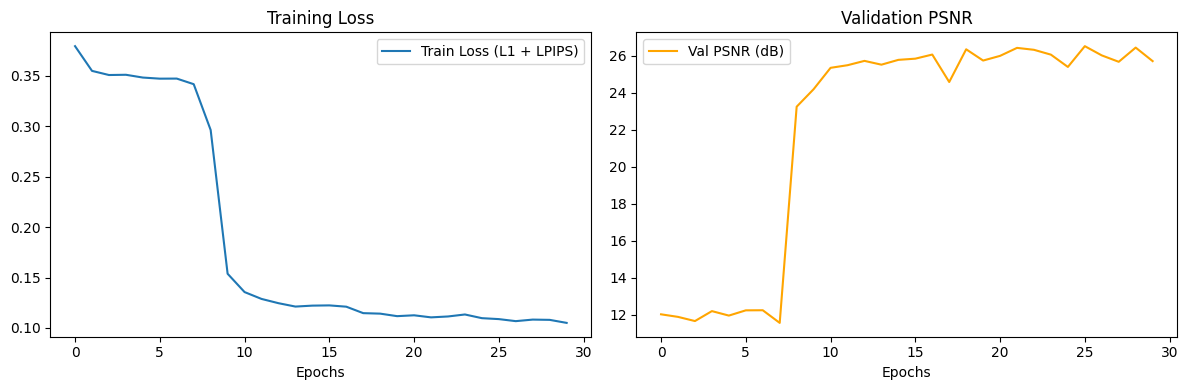

In [9]:
# Cell 5: Training Loop
EPOCHS = 30
history = {'train_loss': [], 'val_psnr': [], 'val_ssim': []}

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    
    for noisy, gt in train_loader:
        noisy, gt = noisy.to(device).float(), gt.to(device).float()
        
        optimizer.zero_grad()
        pred = model(noisy)
        
        loss, _, _ = criterion(pred, gt)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_train_loss = epoch_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)
    
    # Validation Phase
    model.eval()
    val_psnr, val_ssim = 0, 0
    
    with torch.no_grad():
        for noisy, gt in val_loader:
            noisy, gt = noisy.to(device).float(), gt.to(device).float()
            pred = model(noisy)
            
            # Clamp for metrics as human perception is bounded
            pred_clamped = torch.clamp(pred, 0, 1)
            
            val_psnr += psnr_calc(pred_clamped, gt).item()
            val_ssim += ssim_calc(pred_clamped, gt).item()
            
    avg_psnr = val_psnr / len(val_loader)
    avg_ssim = val_ssim / len(val_loader)
    
    history['val_psnr'].append(avg_psnr)
    history['val_ssim'].append(avg_ssim)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_train_loss:.4f} | Val PSNR: {avg_psnr:.2f} dB | Val SSIM: {avg_ssim:.4f}")

# Plotting metrics
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss (L1 + LPIPS)')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_psnr'], label='Val PSNR (dB)', color='orange')
plt.title('Validation PSNR')
plt.xlabel('Epochs')
plt.legend()
plt.tight_layout()
plt.show()

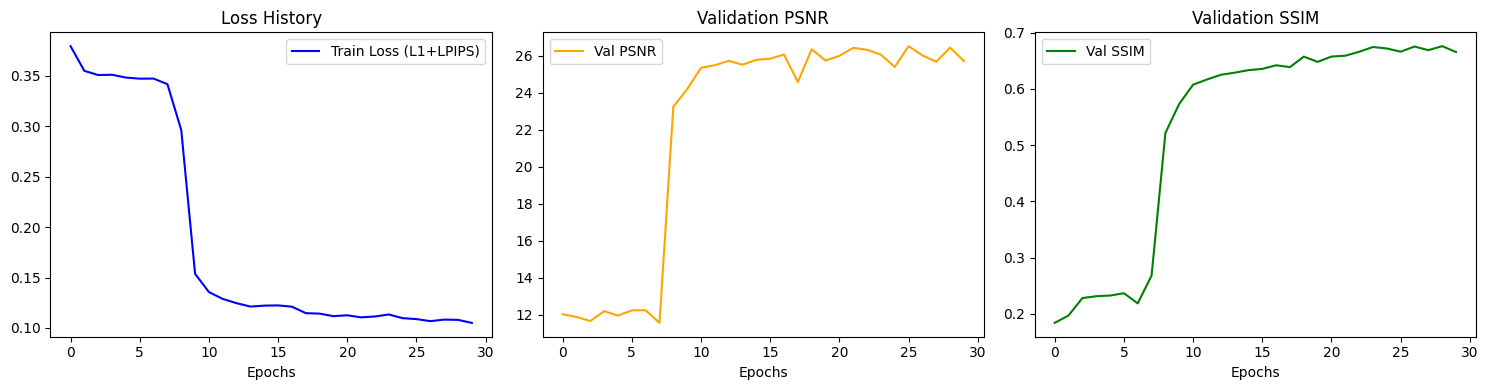

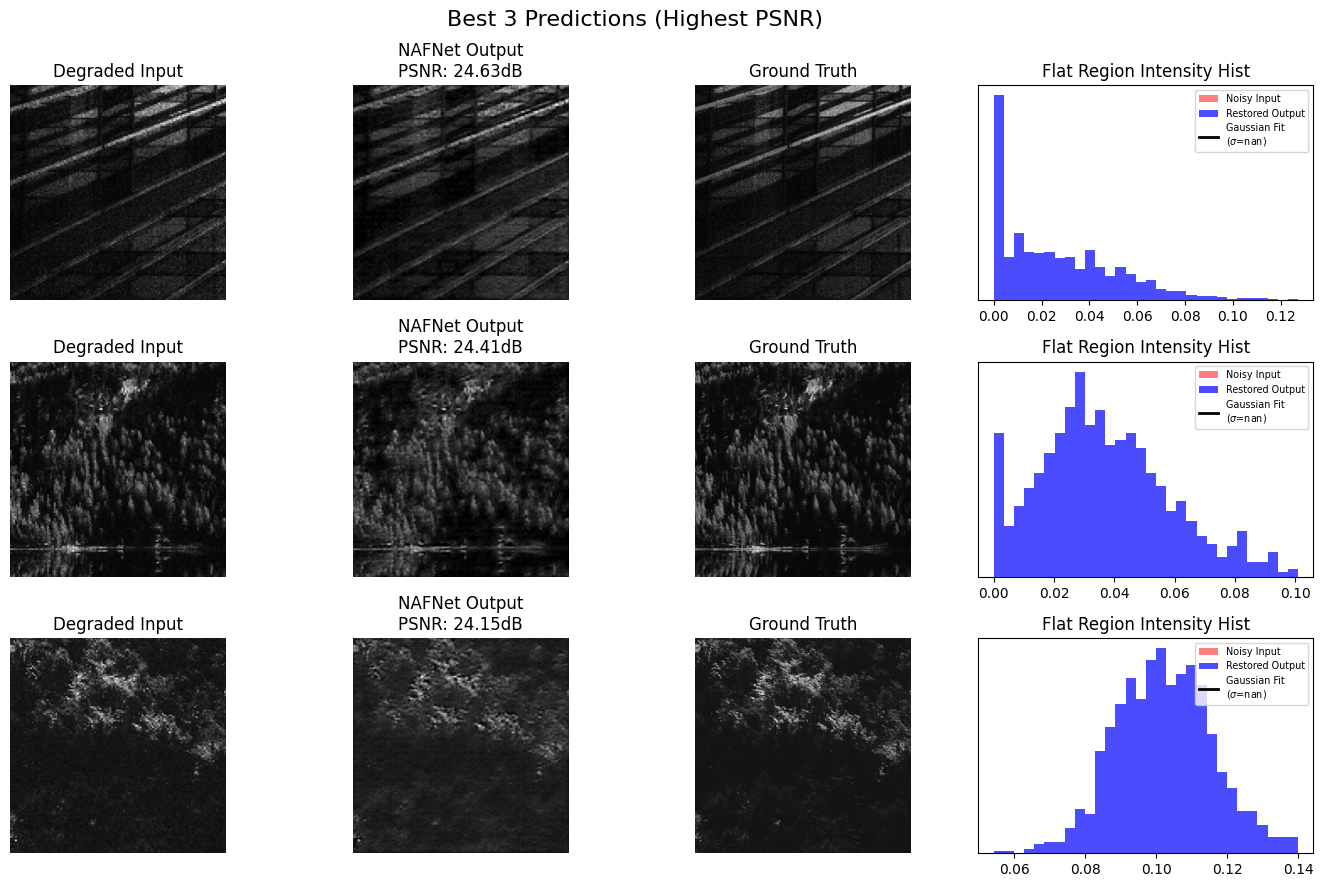

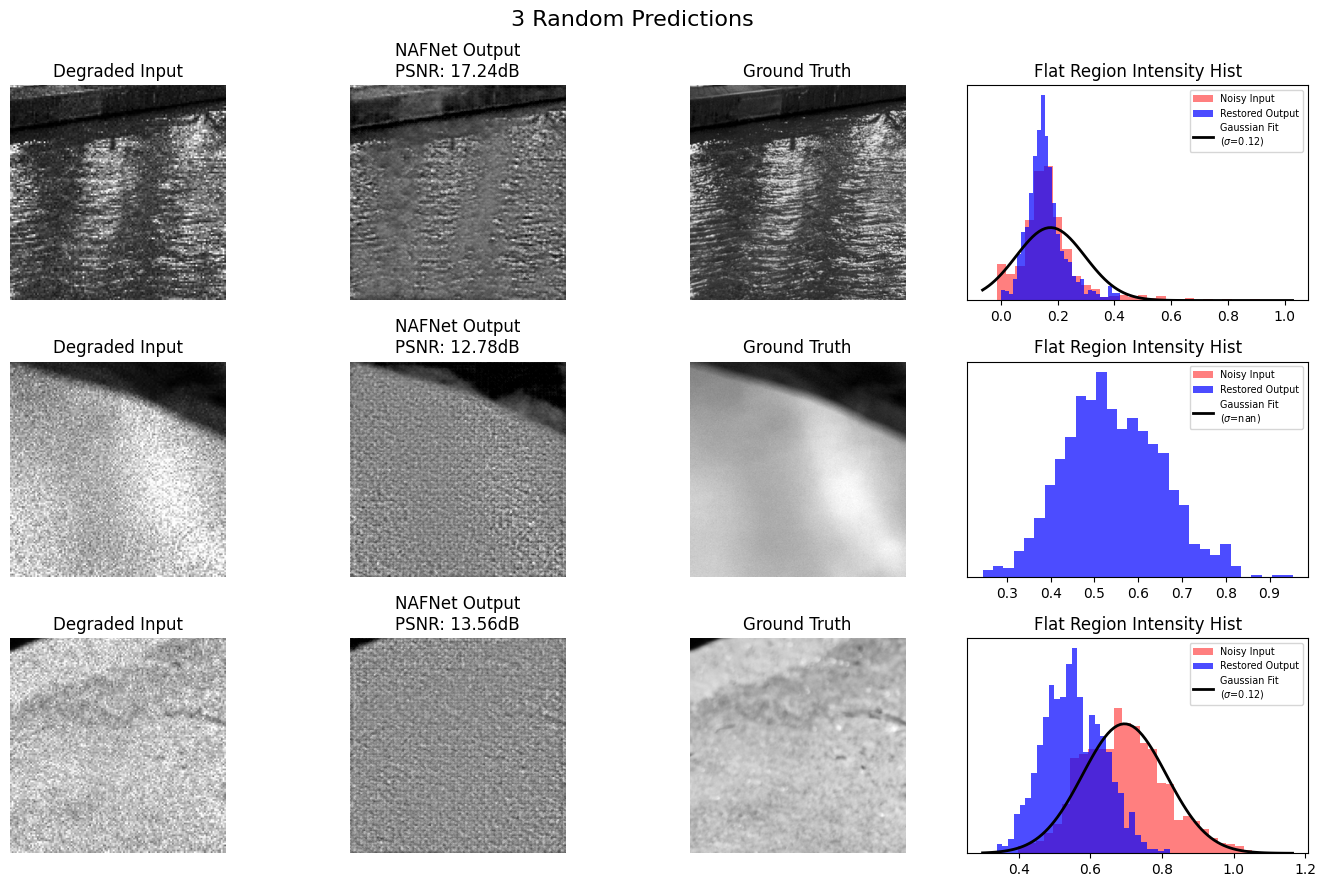

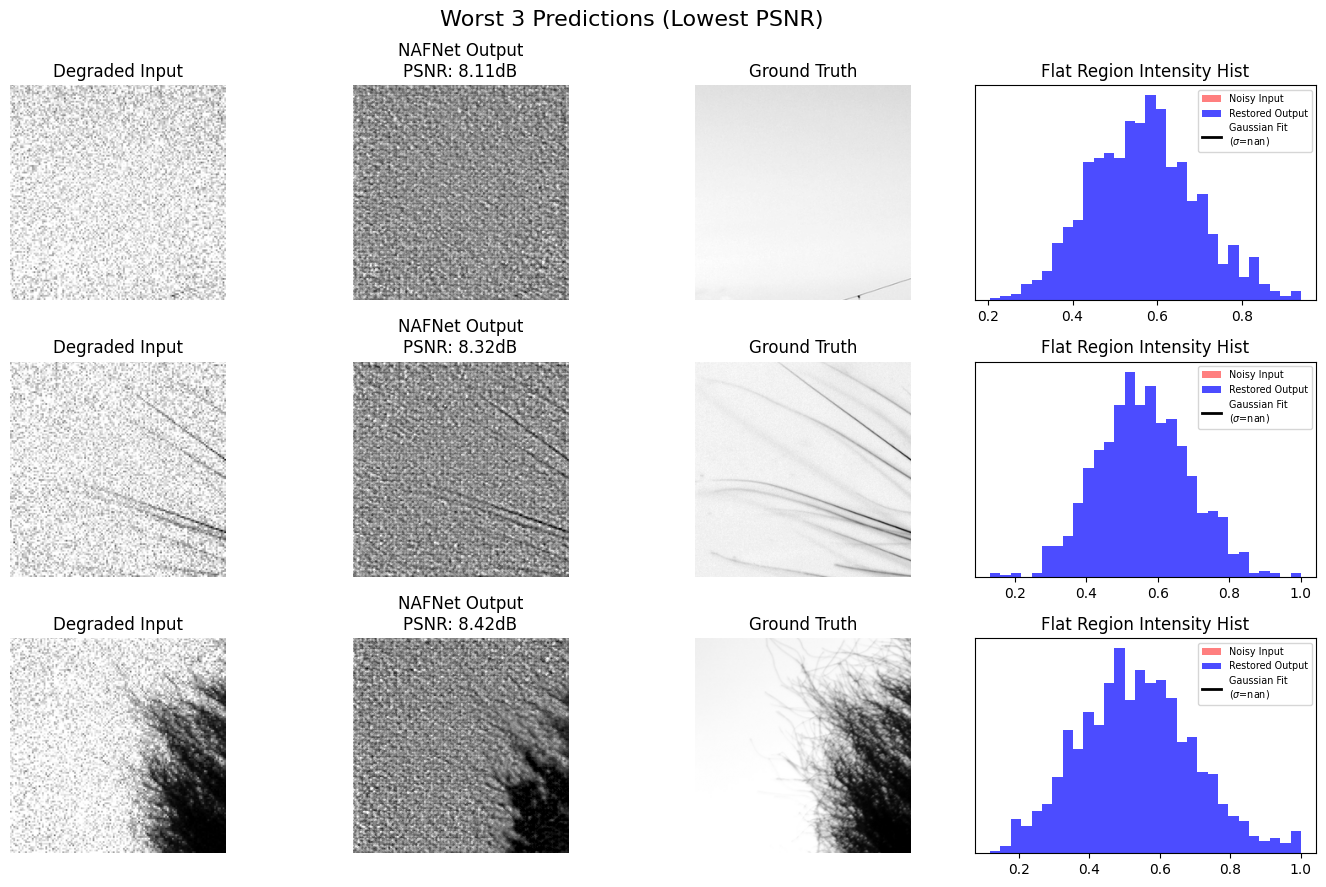

In [16]:
# Cell 6: Visualize Best, Random, Worst + Noise Histograms

import scipy.stats as stats

# ---------------------------------------------------------
# 1. Plot Training / Validation History
# ---------------------------------------------------------
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
if 'val_loss' in history:
    plt.plot(history['val_loss'], label='Val Loss', color='red')
plt.plot(history['train_loss'], label='Train Loss (L1+LPIPS)', color='blue')
plt.title('Loss History')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['val_psnr'], label='Val PSNR', color='orange')
plt.title('Validation PSNR')
plt.xlabel('Epochs')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['val_ssim'], label='Val SSIM', color='green')
plt.title('Validation SSIM')
plt.xlabel('Epochs')
plt.legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 2. Extract Flat Regions & Visualize Predictions
# ---------------------------------------------------------
def get_flat_patch_coords(img, size=32):
    """
    Slides a window across the image to find the patch with the lowest variance.
    This guarantees we are analyzing an empty/flat surface.
    """
    h, w = img.shape
    min_var = float('inf')
    best_r, best_c = 0, 0
    step = max(1, size // 2)
    
    for r in range(0, h - size + 1, step):
        for c in range(0, w - size + 1, step):
            var = np.var(img[r:r+size, c:c+size])
            if var < min_var:
                min_var = var
                best_r, best_c = r, c
                
    return best_r, best_c

model.eval()
results_cache = []

with torch.no_grad():
    for noisy, gt in val_loader:
        noisy_device = noisy.to(device).float()
        pred = model(noisy_device)
        pred_clamped = torch.clamp(pred, 0, 1)
        
        psnr_val = psnr_calc(pred_clamped, gt.to(device).float()).item()
        
        results_cache.append({
            'psnr': psnr_val,
            'noisy': noisy.squeeze().cpu().numpy(),
            'pred': pred_clamped.squeeze().cpu().numpy(),
            'gt': gt.squeeze().cpu().numpy()
        })

results_cache.sort(key=lambda x: x['psnr'])

worst_3 = results_cache[:3]
best_3 = results_cache[-3:][::-1] 
random_3 = random.sample(results_cache[3:-3], 3) 

def plot_samples_with_histogram(samples, title):
    # Expanded to 4 columns to fit the noise histogram
    fig, axes = plt.subplots(len(samples), 4, figsize=(14, 3 * len(samples)))
    fig.suptitle(title, fontsize=16)
    
    for i, sample in enumerate(samples):
        noisy_img = sample['noisy']
        pred_img = sample['pred']
        gt_img = sample['gt']
        
        axes[i, 0].imshow(noisy_img, cmap='gray', vmin=0, vmax=1)
        axes[i, 0].set_title(f"Degraded Input")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(pred_img, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title(f"NAFNet Output\nPSNR: {sample['psnr']:.2f}dB")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(gt_img, cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title(f"Ground Truth")
        axes[i, 2].axis('off')
        
        # --- Noise Histogram Logic ---
        patch_size = 32
        
        # 1. Find the coordinates of the flattest region in the Ground Truth
        r, c = get_flat_patch_coords(gt_img, size=patch_size)
        
        # 2. Extract that same region from the noisy input and the network's prediction
        noisy_patch = noisy_img[r:r+patch_size, c:c+patch_size].flatten()
        pred_patch = pred_img[r:r+patch_size, c:c+patch_size].flatten()
        
        # 3. Plot the intensity distribution
        axes[i, 3].hist(noisy_patch, bins=30, alpha=0.5, color='red', density=True, label='Noisy Input')
        axes[i, 3].hist(pred_patch, bins=30, alpha=0.7, color='blue', density=True, label='Restored Output')
        
        # 4. Fit and overlay a bell-shaped Normal (Gaussian) curve to the Noisy patch
        mu, std = np.mean(noisy_patch), np.std(noisy_patch)
        xmin, xmax = axes[i, 3].get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p = stats.norm.pdf(x, mu, std)
        
        axes[i, 3].plot(x, p, 'k', linewidth=2, label=f'Gaussian Fit\n($\sigma$={std:.2f})')
        axes[i, 3].set_title("Flat Region Intensity Hist")
        axes[i, 3].legend(fontsize='x-small', loc='upper right')
        axes[i, 3].set_yticks([]) # Clean up y-axis

    plt.tight_layout()
    plt.show()

# Render the plots
plot_samples_with_histogram(best_3, "Best 3 Predictions (Highest PSNR)")
plot_samples_with_histogram(random_3, "3 Random Predictions")
plot_samples_with_histogram(worst_3, "Worst 3 Predictions (Lowest PSNR)")